In [2]:
import pandas as pd
import hashlib as hl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df_program = pd.read_csv("athlete_events.csv")

##filtrerar ut Frankrike för sommar OS
fra_summer = df_program[(df_program["Team"] == "France") & (df_program["Season"] == "Summer")].copy()

df_program["Name"] = df_program["Name"].apply(lambda x:hl.sha256(str(x).encode("utf-8")).hexdigest())

print(df_program.head())

   ID                                               Name Sex   Age  Height  \
0   1  3a4eef48434c66b3f14ab0221f6762d0ef7c6135ab2790...   M  24.0   180.0   
1   2  a6430cc6630934275dc6283f7e97e9625e6587cdddec7a...   M  23.0   170.0   
2   3  9c198b205332c2c8e1542e0f9534b9e270780a41d978ec...   M  24.0     NaN   
3   4  0a477bb1c5ad39716f9c775e54d18d16aa8b37ada55548...   M  34.0     NaN   
4   5  5b7be356aa28178096dc6747f0b8e4e393eaceb5f95310...   F  21.0   185.0   

   Weight            Team  NOC        Games  Year  Season       City  \
0    80.0           China  CHN  1992 Summer  1992  Summer  Barcelona   
1    60.0           China  CHN  2012 Summer  2012  Summer     London   
2     NaN         Denmark  DEN  1920 Summer  1920  Summer  Antwerpen   
3     NaN  Denmark/Sweden  DEN  1900 Summer  1900  Summer      Paris   
4    82.0     Netherlands  NED  1988 Winter  1988  Winter    Calgary   

           Sport                             Event Medal  
0     Basketball       Basketball Men's

In [3]:
#rensar medaljkolumnen
fra_medals = df_program[df_program["Medal"].notna()]

In [4]:
# Frankrikes medaljer filtreras
fra_medals = df_program[(df_program["Team"] == "France") & (df_program["Medal"].notna())]

# Medalj per sport
medals_per_sport = (fra_medals.groupby("Sport")["Medal"].count().sort_values(ascending=False))

print(medals_per_sport)

px.bar(medals_per_sport, title="Frankrikes medaljer")

#px.line(medals_per_sport, title="Antal medaljer")

Sport
Fencing                  310
Cycling                  151
Athletics                110
Rowing                    89
Handball                  77
Equestrianism             77
Swimming                  71
Shooting                  69
Gymnastics                58
Canoeing                  49
Judo                      49
Archery                   48
Alpine Skiing             45
Biathlon                  40
Basketball                38
Rugby                     34
Sailing                   25
Boxing                    25
Tennis                    22
Wrestling                 17
Water Polo                16
Weightlifting             16
Football                  16
Art Competitions          15
Freestyle Skiing          12
Figure Skating            10
Snowboarding              10
Croquet                    8
Taekwondo                  7
Nordic Combined            7
Modern Pentathlon          7
Cross Country Skiing       5
Bobsleigh                  4
Curling                    4
Military

In [5]:
#räknar medaljer per sport
medals_per_sport = fra_medals.groupby("Sport")["Medal"].count().sort_values(ascending=False)
print(medals_per_sport)

Sport
Fencing                  310
Cycling                  151
Athletics                110
Rowing                    89
Handball                  77
Equestrianism             77
Swimming                  71
Shooting                  69
Gymnastics                58
Canoeing                  49
Judo                      49
Archery                   48
Alpine Skiing             45
Biathlon                  40
Basketball                38
Rugby                     34
Sailing                   25
Boxing                    25
Tennis                    22
Wrestling                 17
Water Polo                16
Weightlifting             16
Football                  16
Art Competitions          15
Freestyle Skiing          12
Figure Skating            10
Snowboarding              10
Croquet                    8
Taekwondo                  7
Nordic Combined            7
Modern Pentathlon          7
Cross Country Skiing       5
Bobsleigh                  4
Curling                    4
Military

In [6]:
px.bar(medals_per_sport, title="Frankrikes medaljer per sport")

In [7]:
#antal medaljer per OS
medals_per_games = fra_medals.groupby("Games")["Medal"].count()

px.line(medals_per_games, title="Antal medaljer per OS (Frankrike)")

In [8]:
fra_age = df_program[df_program["Age"].notna()]

px.histogram(fra_age, x="Age", nbins=30,
             title="Åldersfördelning för franska OS-idrottare")

In [9]:
sports = ["Fencing", "Athletics", "Cycling", "Swimming"]
df_sports = df_program[df_program["Sport"].isin(sports)]

In [10]:
df_medals = df_sports[df_sports["Medal"].notna()]

medals_by_country = df_medals.groupby(["Sport", "Team"])["Medal"].count().reset_index()


px.bar(medals_by_country,x="Team", y="Medal", color="Sport",title="Medaljfördelning i utvalda sporter", width=800, height=500)


In [11]:
df_age = df_sports[df_sports["Age"].notna()]

px.histogram(df_age, x="Age", color="Sport", barmode="overlay",
             title="Åldersfördelning i sporterna")

In [12]:
fra_medals = df_program[df_program["Medal"].notna()]
fra_medals["Medal"].count()

np.int64(39783)

In [13]:
fra_medals["Medal"].value_counts()

Medal
Gold      13372
Bronze    13295
Silver    13116
Name: count, dtype: int64

In [14]:
import plotly.express as px

medals_per_sport = fra_medals.groupby("Sport")["Medal"].count().sort_values(ascending=False)

px.bar(medals_per_sport, title="Frankrikes medaljer per sport, Sommar-OS")


Antal rader för France: 11988
     ID                                               Name Sex   Age  Height  \
98   34  f55d2538e2894e8989e9e4c980e655fceb9a26bc0206f7...   M  30.0   187.0   
145  52  0a233c98a85ac1a48fbfea66cbdd0854f358ee489ccff0...   M  22.0   189.0   
149  56  1b8c926b7a11c580396202a098140668ef85328a14050a...   M  21.0     NaN   
150  56  1b8c926b7a11c580396202a098140668ef85328a14050a...   M  21.0     NaN   
173  73  277d20d8e003ceb8c9e1e2e1c570b972e9d3ea94543378...   M  23.0   182.0   

     Weight    Team  NOC        Games  Year  Season       City      Sport  \
98     76.0  France  FRA  2012 Summer  2012  Summer     London  Athletics   
145    80.0  France  FRA  1976 Summer  1976  Summer   Montreal  Athletics   
149     NaN  France  FRA  1956 Summer  1956  Summer  Melbourne    Cycling   
150     NaN  France  FRA  1956 Summer  1956  Summer  Melbourne    Cycling   
173    86.0  France  FRA  2008 Summer  2008  Summer    Beijing   Handball   

                          

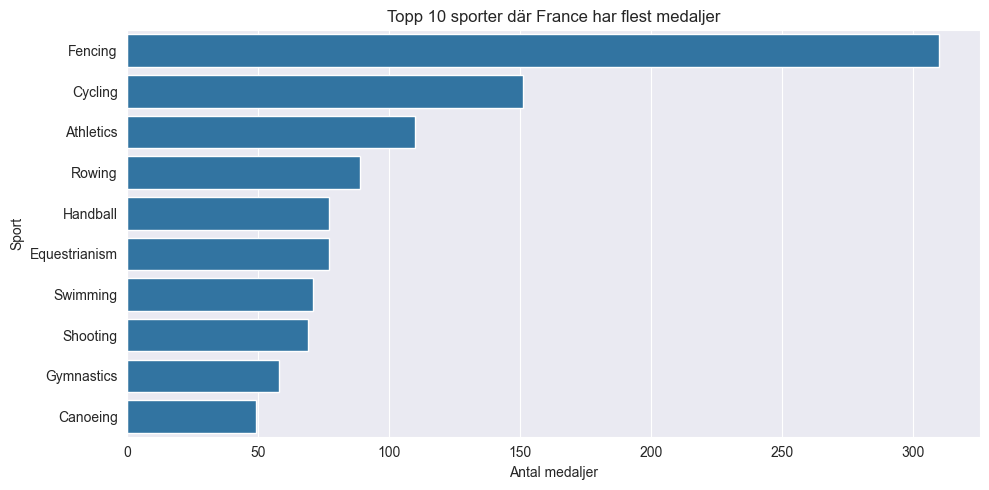

In [15]:
country = "France"
country_df = df_program[df_program['Team'] == country]

print(f"Antal rader för {country}: {len(country_df)}")
print(country_df.head())

medals = country_df.dropna(subset=["Medal"])

medals_per_sport = medals.groupby("Sport")["Medal"].count().sort_values(ascending=False)
print(medals_per_sport.head(10))


plt.figure(figsize=(10,5))
sns.barplot(x=medals_per_sport.head(10).values, y=medals_per_sport.head(10).index)
plt.title(f"Topp 10 sporter där {country} har flest medaljer")
plt.xlabel("Antal medaljer")
plt.ylabel("Sport")
plt.tight_layout()
plt.show()

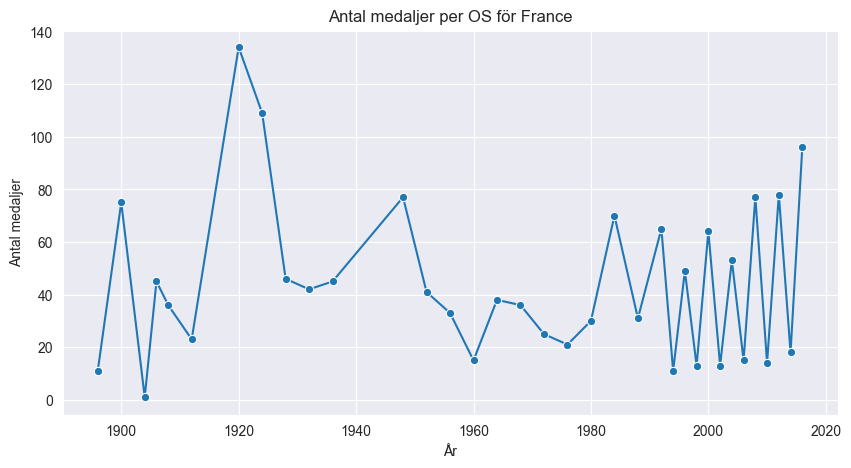

In [16]:
#antal medaljer per OS år
medals_per_year = medals.groupby("Year")["Medal"].count()

plt.figure(figsize=(10,5))
sns.lineplot(x=medals_per_year.index, y=medals_per_year.values, marker="o")
plt.title(f"Antal medaljer per OS för {country}")
plt.xlabel("År")
plt.ylabel("Antal medaljer")
plt.grid(True)
plt.show()


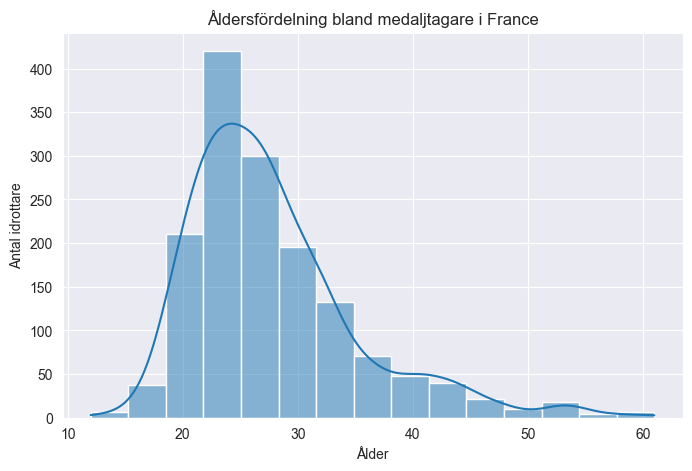

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=medals, x="Age", bins=15, kde=True)
plt.title(f"Åldersfördelning bland medaljtagare i {country}")
plt.xlabel("Ålder")
plt.ylabel("Antal idrottare")
plt.show()


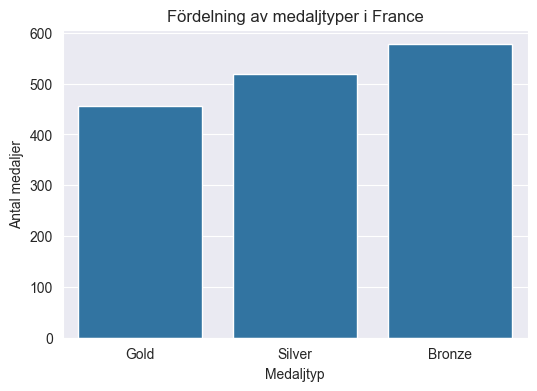

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=medals, x="Medal", order=["Gold","Silver","Bronze"])
plt.title(f"Fördelning av medaljtyper i {country}")
plt.xlabel("Medaljtyp")
plt.ylabel("Antal medaljer")
plt.show()


<Axes: xlabel='Year'>

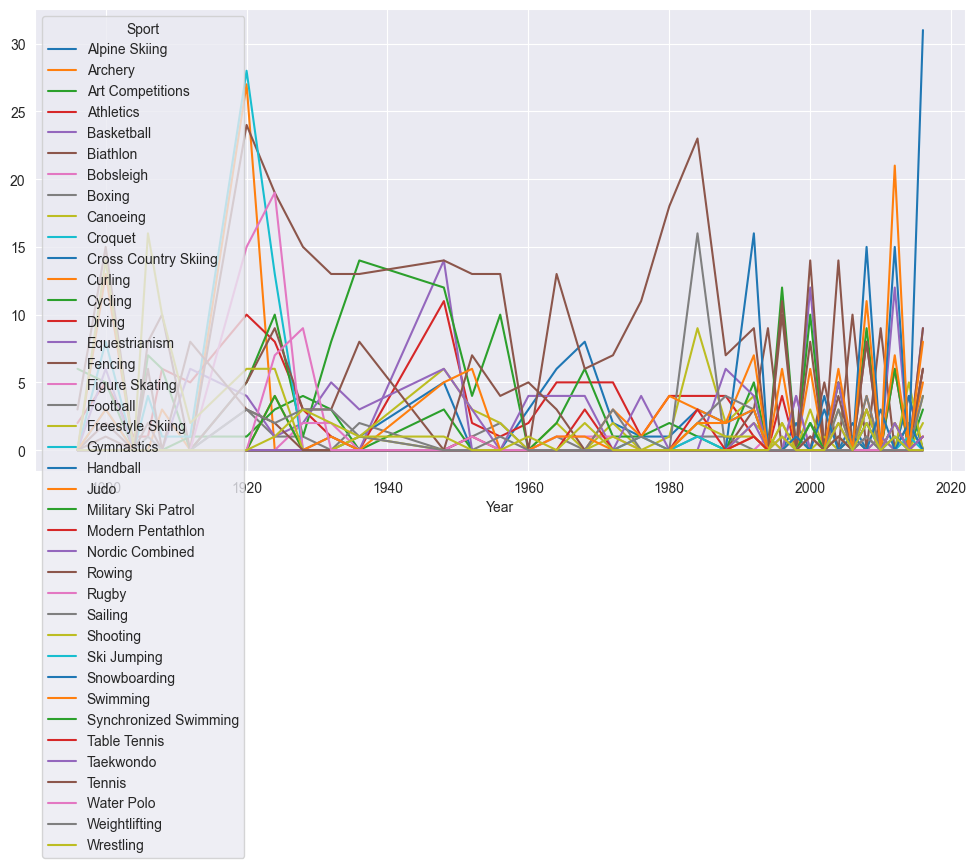

In [19]:
medals_france = df_program[(df_program['Team'] == 'France') & df_program['Medal'].notna()]
medals_by_sport_year = medals_france.groupby(['Year', 'Sport']).size().unstack(fill_value=0)
medals_by_sport_year.plot(figsize=(12,6))


<Axes: xlabel='Year', ylabel='Count'>

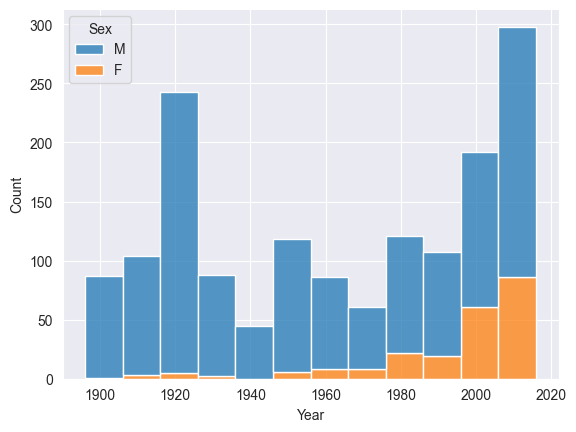

In [20]:
#könsfördelning mellan medaljörer
sns.histplot(data=medals_france, x='Year', hue='Sex', multiple='stack')


<Axes: xlabel='Season', ylabel='count'>

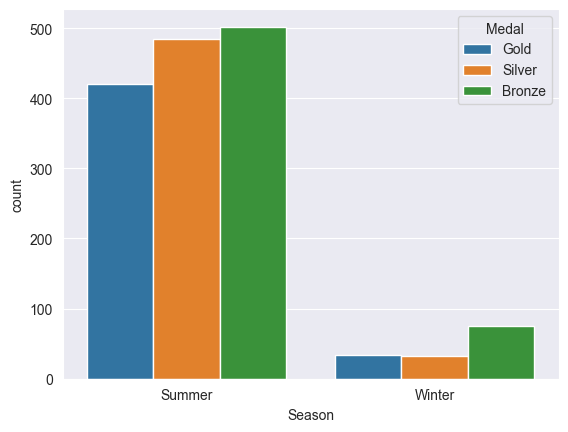

In [21]:
#medalj jämförelse mellan sommar och vinter OS
sns.countplot(data=medals_france, x='Season', hue='Medal')

<Axes: xlabel='Height', ylabel='Weight'>

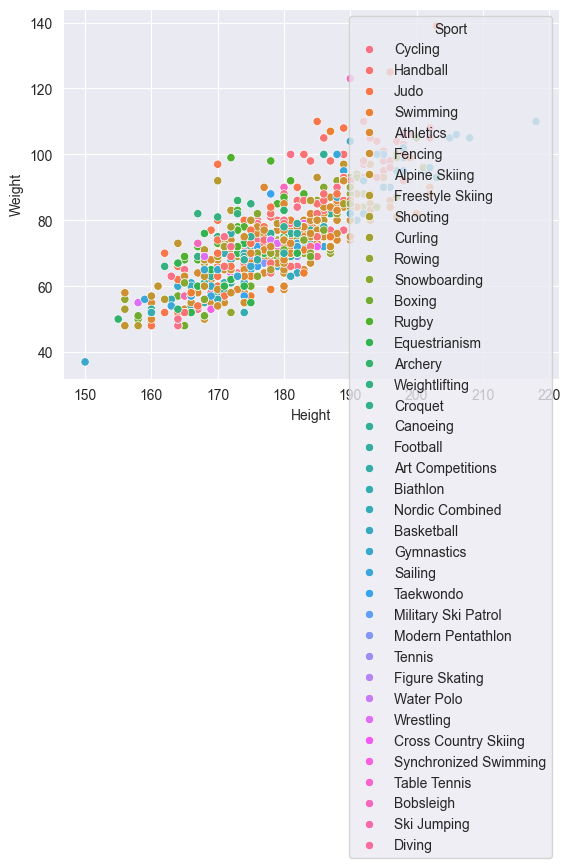

In [23]:
#kroppslängd/vikt per sport
sns.scatterplot(data=medals_france, x='Height', y='Weight', hue='Sport')

<Axes: xlabel='Sex', ylabel='Age'>

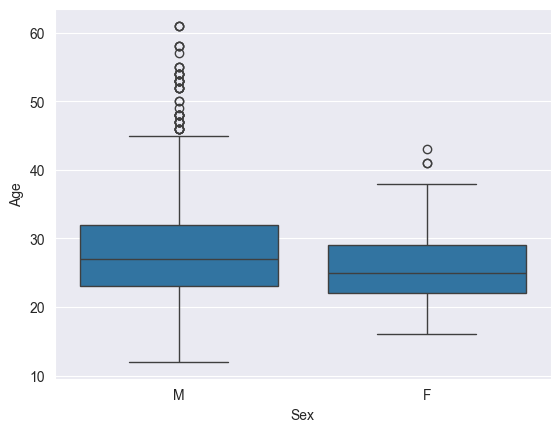

In [25]:
#ålderskillnad mellan manliga och kvinnliga medaljörer
sns.boxplot(data=medals_france, x='Sex', y='Age')


<Axes: title={'center': 'Antal franska deltagare per OS'}, xlabel='Year'>

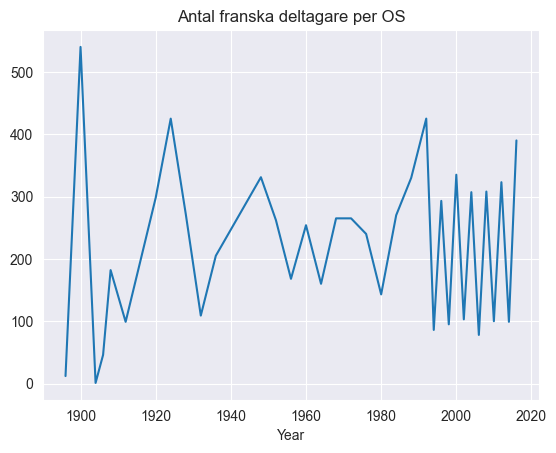

In [27]:
participants_fr = df_program[df_program["Team"]=="France"].groupby("Year")["ID"].nunique()
participants_fr.plot(title="Antal franska deltagare per OS")